# Ćwiczenia 9: podstawy statystyki z modułem SciPy

## Ćwiczenie 0.

Zaimportuj moduł Pandas oraz SciPy. Zaimportuj zestaw danych *environmental* i przygotuj do pracy.

In [2]:
import pandas as pd
import scipy 

In [3]:
sites = pd.read_csv("data/environmental/environmental/sites.csv", index_col="site_name").drop(columns=["comment"])

samples = pd.read_csv("data/environmental/environmental/samples.csv", index_col="sample_id").drop(columns=["comment"])
samples = samples.merge(sites, left_on="site", right_index=True, how="inner")[['site', 
                  'latitude', 'longitude', 'human_activity', 'season', 'depth', 'molecule', 'rep_number', 'temperature', 'humidity', 
                  'particles']]

taxa_db = pd.read_csv("data/environmental/environmental/taxa_db.csv", index_col=0)
taxonomy = pd.read_csv("data/environmental/environmental/taxonomy.csv", index_col="hash_id")
taxonomy = taxonomy.merge(taxa_db, left_on="taxonomy", right_index=True, how="inner")[['taxonomy_y', 'percentage']]
taxonomy.columns = ['taxonomy', 'percentage']

biom = pd.read_csv("data/environmental/environmental/biom.csv")
biom.index = biom.iloc[:, 0]
biom = biom.drop(columns=biom.columns[0])
biom.index.name = "sample_id"
biom = biom.map(lambda x: 0 if not isinstance(x, int) else x)

/tmp/ipykernel_271609/2500478325.py:13: DtypeWarning: Columns (0: 472d6c64d9d6633b8c7f4274920e0cde, 1: 6f204260468164ceb0e1d91f85402c04, 2: 739ada9f31394fcf327418d8f280129e, 3: 3e10b8b318edd2f617fd15e457f49235, 4: 73fac5248ad262fb38745224496bd195, 5: 3a5cc8e9b107a5eaed65ba1e2ce669b2, 6: 36e2c62b8cd2e888684654579d068bbe, 7: 3967d6567f6c61251d25d8447aeaea57, 8: 4fae68d9518c4b0bbc18dfb7c0cfbeb4, 9: 22e216e70b9fa7561a30c8f571222b58, 10: 064fa82e8050ac315318c8f558c35fb6, 11: deee2bb1e0305d2ecfd55542f2934125, 12: 1d16dcaa0a452eb436741e2e67169d21, 13: 5dadfdaeed7424af8f551d4e5cc607bc, 14: e19f1ae5606d8bb22254cf86aa6bd6ec, 15: 3237d77e6efcf7970e4b1edaf8184c87, 16: 2a978407835f6a0477e4e6200e4775c6, 17: 1e9af98c27e6af70d546802f830381a7, 18: ef4a7352931cc2f25f7f6af594fcc19b, 19: d94e0a77869f314e25619a4d455f64d7, 20: 319b12de3affc7e857788bd31e2fa2b3, 21: 540d71832489fd0940a54396a15ce1e4, 22: 98f620d1944f2a859e35ce47ae77ec19, 23: 28ad22b5898c86e508c90f959631cb61, 24: cfac33b5f31c388f6f4293bcfac228a

In [4]:
samples.isna().sum()

site              0
latitude          0
longitude         0
human_activity    0
season            0
depth             0
molecule          0
rep_number        0
temperature       0
humidity          0
particles         0
dtype: int64

In [5]:
samples.describe()

,latitude,longitude,depth,rep_number,temperature,humidity,particles
count,1530.000000,1530.000000,1530.000000,1530.000000,1530.000000,1530.000000,1530.000000
mean,51.715531,19.874782,50.000000,3.000000,17.050980,57.450980,505.885507
std,0.828097,2.262625,24.502906,1.414676,8.552612,30.626367,306.364822
min,50.312115,15.493592,20.000000,1.000000,-4.000000,-23.000000,-389.823063
25%,51.067421,18.228474,20.000000,2.000000,12.000000,31.000000,300.558213
50%,51.904229,20.542271,50.000000,3.000000,16.000000,59.000000,513.326602
75%,52.088223,21.528566,80.000000,4.000000,22.000000,81.000000,713.012527
max,53.039363,22.739079,80.000000,5.000000,44.000000,129.000000,1554.307888


<Axes: >

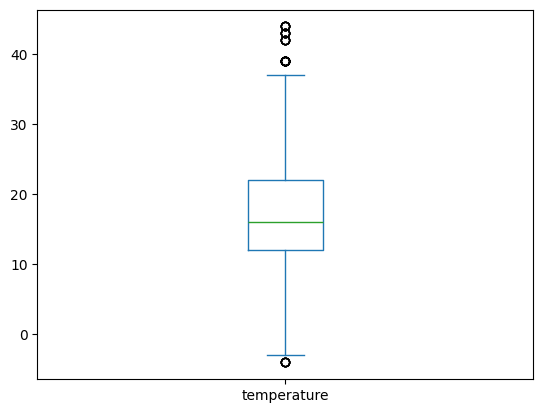

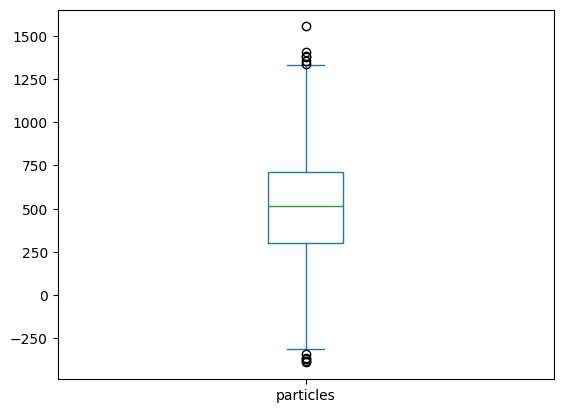

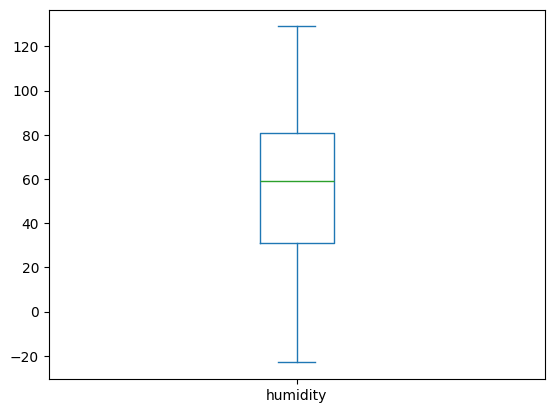

In [6]:
samples[['temperature']].plot(kind = 'box');samples[['particles']].plot(kind = 'box');samples[['humidity']].plot(kind = 'box')

In [7]:
samples = samples[(samples.temperature < 35) & (0 < samples.humidity) & (samples.humidity < 100) & (samples.particles >= 0) & (samples.particles < 1000)]

In [8]:
taxonomy.isna().sum()

taxonomy      0
percentage    0
dtype: int64

In [9]:
taxonomy.describe()

,percentage
count,3949.000000
mean,98.473662
std,1.441840
min,91.029628
25%,97.873126
50%,98.885349
75%,99.529270
max,99.998977


## Ćwiczenie 1. Testowanie założeń

Wiele testów statystycznych wymaga aby dane spełniały określone założenia. Na przykład test t-Studenta zakłada, że porównywane zmienne losowe mają rozkład normalny. Oznacza to, że wynik testu t-Studenta przeprowadzony na danych, które nie mają rozkładu normalnego jest niewiarygodny.

### Zadanie

Wykonaj test normalności Shapiro-Wilka na wszystkich zmiennych liczbowych z tabeli samples.
Wykonaj test niezależności wszystkich par zmiennych liczbowych z tabeli samples.

In [10]:
def test_normalnosci(zmienna_losowa):
    statistic, p = scipy.stats.shapiro(zmienna_losowa)
    print(f'Wartość statystyki testowej = {statistic:.3f}, p-value = {p:.3f}')
    if p < 0.05:
        print('Zmienna nie ma rozkładu normalnego')
    else:
        print('Zmienna ma rozkłąd normalny')
    

In [11]:
samples.head()

,site,latitude,longitude,human_activity,season,depth,molecule,rep_number,temperature,humidity,particles
sample_id,,,,,,,,,,,
1,site_1,52.044225,18.228474,urban,spring,20.0,DNA,1.0,13.0,48.0,487.171474
2,site_1,52.044225,18.228474,urban,spring,20.0,RNA,1.0,13.0,48.0,561.125523
3,site_1,52.044225,18.228474,urban,spring,50.0,DNA,1.0,13.0,48.0,315.156923
5,site_1,52.044225,18.228474,urban,spring,80.0,DNA,1.0,13.0,48.0,282.204666
6,site_1,52.044225,18.228474,urban,spring,80.0,RNA,1.0,13.0,48.0,487.280159


In [12]:
test_normalnosci(samples.temperature)
test_normalnosci(samples.humidity)
test_normalnosci(samples.particles)

Wartość statystyki testowej = 0.993, p-value = 0.000
Zmienna nie ma rozkładu normalnego
Wartość statystyki testowej = 0.953, p-value = 0.000
Zmienna nie ma rozkładu normalnego
Wartość statystyki testowej = 0.981, p-value = 0.000
Zmienna nie ma rozkładu normalnego


In [13]:
def test_niezaleznosci(zmienna1, zmienna2):
   statistics, p = scipy.stats.levene(zmienna1, zmienna2)
   print(f'Wartość statystyki testowej = {statistics:.3f}, p-value = {p:.3f}')
   if p < 0.05:
        print('Zmienne są zależne')
   else:
        print('Zmienne są niezależne')

    

In [14]:
test_niezaleznosci(samples.temperature, samples.humidity)
test_niezaleznosci(samples.temperature, samples.particles)
test_niezaleznosci(samples.humidity, samples.particles)


Wartość statystyki testowej = 1707.897, p-value = 0.000
Zmienne są zależne
Wartość statystyki testowej = 2488.003, p-value = 0.000
Zmienne są zależne
Wartość statystyki testowej = 2062.732, p-value = 0.000
Zmienne są zależne


## Ćwiczenie 2. Testowanie hipotez

Przetestuj następujące hipotezy:
* średnia temperatura latem jest istotnie wyższa niż wiosną i jesienią
* średnia wilgotność powietrza jesienią jest istotnie wyższa niż wiosną
* średnia liczba ASV w próbkach na DNA jest istotnie niższa niż w próbkach na RNA
* średnia liczba cząsteczek na głębokości 80 cm jest istotnie wyższa niż na głębokości 20 cm
* średnia bioróżnorodność na południu kraju jest istotnie wyższa niż na północy

# H0
h0: EX_lato <= EX_wiosna i EX_lato <= EX_jesien

h1 : EX_lato > EX_wiosna i EX_lato > EX_jesien

<Axes: xlabel='season'>

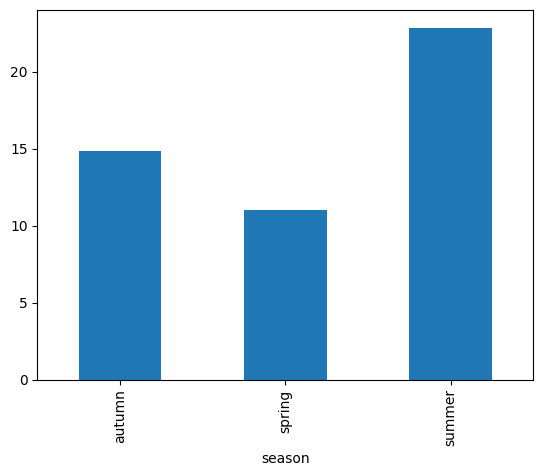

In [15]:
# to tylko moje sprawdzenie, czy wszystko działa, nie jest częścią zadania
zmienna =samples.groupby("season").temperature.mean()
zmienna.plot(kind="bar")

In [16]:
temp_lato = samples[samples.season == "summer"].temperature
temp_wiosna = samples[samples.season == "spring"].temperature
temp_jesien = samples[samples.season == "autumn"].temperature

In [17]:
temp_lato

sample_id
31      15.0
32      15.0
33      15.0
34      15.0
35      15.0
        ... 
1406    16.0
1407    16.0
1408    16.0
1409    16.0
1410    16.0
Name: temperature, Length: 393, dtype: float64

In [18]:
test_normalnosci(temp_lato)
test_normalnosci(temp_wiosna)
test_normalnosci(temp_jesien)

Wartość statystyki testowej = 0.976, p-value = 0.000
Zmienna nie ma rozkładu normalnego
Wartość statystyki testowej = 0.984, p-value = 0.000
Zmienna nie ma rozkładu normalnego
Wartość statystyki testowej = 0.942, p-value = 0.000
Zmienna nie ma rozkładu normalnego


In [19]:
test_niezaleznosci(temp_lato, temp_wiosna)
test_niezaleznosci(temp_lato, temp_jesien)
test_niezaleznosci(temp_wiosna, temp_jesien)

Wartość statystyki testowej = 8.092, p-value = 0.005
Zmienne są zależne
Wartość statystyki testowej = 0.216, p-value = 0.642
Zmienne są niezależne
Wartość statystyki testowej = 8.632, p-value = 0.003
Zmienne są zależne


In [20]:
temp_lato.size

393

In [21]:
temp_jesien.size

414

In [22]:
temp_wiosna.size

398

In [23]:
temp_wiosna = temp_wiosna.iloc[:393]
temp_jesien = temp_jesien.iloc[:393]

In [24]:
scipy.stats.wilcoxon(temp_lato, temp_wiosna)
scipy.stats.wilcoxon(temp_lato, temp_jesien)
#odrzucamy h0 i przyjmujemy h1 

WilcoxonResult(statistic=np.float64(5581.5), pvalue=np.float64(5.707026959674943e-48))

## Ćwiczenie 3. Testowanie hipotez między wieloma zmiennymi

Podstawowe testy statystyczne badają różnice między parami zmiennych losowych. Czasem zachodzi potrzeba porównać więcej niż dwie zmienne równocześnie. Służy do tego analiza wariancji i test ANOVA. Ten test porównuje wariancję wewnątrz grup do wariancji między grupami. Odpowiada na pytanie *czy przynajmniej jedna grupa ma inną średnią niż pozostałe*.

Przetestuj następujące hipotezy:
* średnia liczba ASV istotnie różni się między poszczególnymi powtórzeniami na stanowiskach
* średnia bioróżnorodność istotnie różni się między próbkami z poszczególnych kwadrantów kraju (pólnocny wschód, południowy wschód, północny zachód, południowy zachód) --> do domu

In [25]:
#ASV to sekwencje w tabeli biom
samples["ASV"] = (biom > 0).sum(axis=1)
samples.head()

,site,latitude,longitude,human_activity,season,depth,molecule,rep_number,temperature,humidity,particles,ASV
sample_id,,,,,,,,,,,,
1,site_1,52.044225,18.228474,urban,spring,20.0,DNA,1.0,13.0,48.0,487.171474,4420
2,site_1,52.044225,18.228474,urban,spring,20.0,RNA,1.0,13.0,48.0,561.125523,3125
3,site_1,52.044225,18.228474,urban,spring,50.0,DNA,1.0,13.0,48.0,315.156923,2828
5,site_1,52.044225,18.228474,urban,spring,80.0,DNA,1.0,13.0,48.0,282.204666,4207
6,site_1,52.044225,18.228474,urban,spring,80.0,RNA,1.0,13.0,48.0,487.280159,3036


In [26]:
samples[samples["rep_number"] == 1].ASV

sample_id
1       4420
2       3125
3       2828
5       4207
6       3036
        ... 
1502    3378
1503    3947
1504    4047
1505    2935
1506    2981
Name: ASV, Length: 266, dtype: int64

In [27]:
lista = [samples[samples["rep_number"] == rep ].ASV for rep in range(1,6)]

In [28]:
lista

[sample_id
 1       4420
 2       3125
 3       2828
 5       4207
 6       3036
         ... 
 1502    3378
 1503    3947
 1504    4047
 1505    2935
 1506    2981
 Name: ASV, Length: 266, dtype: int64,
 sample_id
 8       3629
 9       3830
 10      4023
 12      3267
 39      3470
         ... 
 1507    3355
 1508    3853
 1509    4080
 1510    4042
 1511    3636
 Name: ASV, Length: 236, dtype: int64,
 sample_id
 13      3667
 14      2678
 15      3206
 16      2959
 17      3593
         ... 
 1514    3167
 1515    4380
 1516    4062
 1517    3025
 1518    3668
 Name: ASV, Length: 234, dtype: int64,
 sample_id
 19      3528
 21      3286
 23      3407
 24      3139
 49      3249
         ... 
 1520    4303
 1521    4931
 1522    4697
 1523    3405
 1524    3946
 Name: ASV, Length: 237, dtype: int64,
 sample_id
 25      3178
 27      2547
 28      3055
 29      3135
 30      3362
         ... 
 1525    4233
 1526    4025
 1527    3877
 1529    4641
 1530    3949
 Name: ASV, Length:

In [29]:
for zmienna in lista:
    test_normalnosci(zmienna)
    

Wartość statystyki testowej = 0.991, p-value = 0.085
Zmienna ma rozkłąd normalny
Wartość statystyki testowej = 0.996, p-value = 0.838
Zmienna ma rozkłąd normalny
Wartość statystyki testowej = 0.993, p-value = 0.303
Zmienna ma rozkłąd normalny
Wartość statystyki testowej = 0.994, p-value = 0.465
Zmienna ma rozkłąd normalny
Wartość statystyki testowej = 0.995, p-value = 0.711
Zmienna ma rozkłąd normalny


In [30]:
for z1 in lista:
    for z2 in lista:
        test_niezaleznosci(z1, z2)

Wartość statystyki testowej = 0.000, p-value = 1.000
Zmienne są niezależne
Wartość statystyki testowej = 1.844, p-value = 0.175
Zmienne są niezależne
Wartość statystyki testowej = 0.000, p-value = 0.999
Zmienne są niezależne
Wartość statystyki testowej = 1.175, p-value = 0.279
Zmienne są niezależne
Wartość statystyki testowej = 1.491, p-value = 0.223
Zmienne są niezależne
Wartość statystyki testowej = 1.844, p-value = 0.175
Zmienne są niezależne
Wartość statystyki testowej = 0.000, p-value = 1.000
Zmienne są niezależne
Wartość statystyki testowej = 1.790, p-value = 0.182
Zmienne są niezależne
Wartość statystyki testowej = 0.075, p-value = 0.784
Zmienne są niezależne
Wartość statystyki testowej = 0.012, p-value = 0.912
Zmienne są niezależne
Wartość statystyki testowej = 0.000, p-value = 0.999
Zmienne są niezależne
Wartość statystyki testowej = 1.790, p-value = 0.182
Zmienne są niezależne
Wartość statystyki testowej = 0.000, p-value = 1.000
Zmienne są niezależne
Wartość statystyki testow

In [31]:
ANOVA = scipy.stats.f_oneway(*lista)
#znak * oznacza, że lista jest rozpakowywana, czyli każdy element listy jest przekazywany jako osobny argument do funkcji f_oneway.
ANOVA
# nie ma istotnie statystycznych różnic między grupami
#odrzucamy h1 i przyjmujemy h0
#h0: nie ma różnic między grupami
#h1: są różnice między grupami

F_onewayResult(statistic=np.float64(1.2542639433917744), pvalue=np.float64(0.2861946153143303))

średnia bioróżnorodność istotnie różni się między próbkami z poszczególnych kwadrantów kraju (pólnocny wschód, południowy wschód, północny zachód, południowy zachód)

In [32]:
# robimy test shanona w celu sprawdzenia różnorodności mikroorganizmów w próbkach, im wyższa wartość shannona, tym większa różnorodność
samples['shannon'] = biom.apply(lambda row: scipy.stats.entropy(row[row > 0]), axis=1)

In [33]:
# ustalamy środek aby podzielić na 4 grupy
lat_mid = samples['latitude'].median()
lon_mid = samples['longitude'].median()
print(f"Środek: ({lat_mid}, {lon_mid})")

Środek: (51.90422944380589, 20.542270812939687)


In [34]:
def znajdz_polozenie (row):
    # Północny Wschód (NE): wyżej i w prawo
    if row['latitude'] >= lat_mid and row['longitude'] >= lon_mid:
        return 'NE' 
    # Północny Zachód (NW): wyżej i w lewo
    elif row['latitude'] >= lat_mid and row['longitude'] < lon_mid:
        return 'NW' 
    # Południowy Wschód (SE): niżej i w prawo
    elif row['latitude'] < lat_mid and row['longitude'] >= lon_mid:
        return 'SE' 
    # Południowy Zachód (SW): cała reszta (niżej i w lewo)
    else:
        return 'SW'

samples['polozenie'] = samples.apply(znajdz_polozenie, axis=1)

In [35]:
shannon_ne = samples[samples.polozenie == 'NE'].shannon
shannon_nw = samples[samples.polozenie == 'NW'].shannon
shannon_se = samples[samples.polozenie == 'SE'].shannon
shannon_sw = samples[samples.polozenie == 'SW'].shannon

In [36]:
scipy.stats.f_oneway(shannon_ne, shannon_nw, shannon_se, shannon_sw)
# nie ma istotnie statystycznych różnic między grupami
#odrzucamy h1 i przyjmujemy h0
# h0: nie ma różnic między grupami
# h1: są różnice między grupami

F_onewayResult(statistic=np.float64(9.173629471749074), pvalue=np.float64(5.289999145011839e-06))

## Ćwiczenie 4. Testowanie korelacji

Korelacja to test, który bada współzależność dwóch zmiennych losowych. Służy do poszukiwania zależności przyczynowo skutkowych, ale **sama istotność korelacji nie oznacza istnienia związku przyczynowo-skutkowego**. Jest tylko punktem wyjścia do dalszych badań.

Przetestuj następujące hipotezy:
* oceń związek między temperaturą a wilgotnością w próbkach z północy
* oceń związek między porą roku, a temperaturą
* oceń związek między liczbą cząsteczek próbce, a wartością richness w każdej próbce na stanowisku 3 i 4
* oceń związek między głębokością a liczbą cząsteczek w próbkach ze wschodu kraju
* oceń związek między typem molekuły, a bioróżnorodnością Shannona w próbkach na wiosnę

In [37]:
polnoc = samples[samples['latitude'] > 53][['temperature','humidity']]

In [38]:
polnoc.head()

,temperature,humidity
sample_id,,
1081,13.0,96.0
1082,13.0,96.0
1084,13.0,96.0
1085,13.0,96.0
1086,13.0,96.0


In [39]:
test_normalnosci(polnoc.temperature)
test_normalnosci(polnoc.humidity)

Wartość statystyki testowej = 0.912, p-value = 0.000
Zmienna nie ma rozkładu normalnego
Wartość statystyki testowej = 0.933, p-value = 0.000
Zmienna nie ma rozkładu normalnego


In [40]:
#uzyjemy testu korelacji rang Spearmana, bo nie mamy rozkładu normalnego i nie mamy niezależności między zmiennymi
korelacja = scipy.stats.spearmanr(polnoc.temperature, polnoc.humidity)
korelacja
#korelacja jest istotna statystycznie

SignificanceResult(statistic=np.float64(-0.6536356501685282), pvalue=np.float64(1.1885913533228855e-11))

In [41]:
# wnioski : pvalue jest mniejsze niż 0.05, więc odrzucamy h0 i przyjmujemy h1, 
# czyli istnieje istotna statystycznie korelacja między temperaturą a wilgotnością w próbkach z północy. 
# przyjmujemy h1, czyli istnieje istotna statystycznie korelacja między temperaturą a wilgotnością w próbkach z północy.
# h0: nie ma istotnej statystycznie korelacji między temperaturą a wilgotnością w próbkach z północy.
# h1: istnieje istotna statystycznie korelacja między temperaturą a wilgotnością w próbkach z północy.

In [42]:
lato = samples[samples.season == "summer"]['temperature']
wiosna = samples[samples.season == "spring"]['temperature']
jesien = samples[samples.season == "autumn"]['temperature']

In [43]:
test_normalnosci(lato)
test_normalnosci(wiosna)    
test_normalnosci(jesien)

Wartość statystyki testowej = 0.976, p-value = 0.000
Zmienna nie ma rozkładu normalnego
Wartość statystyki testowej = 0.984, p-value = 0.000
Zmienna nie ma rozkładu normalnego
Wartość statystyki testowej = 0.942, p-value = 0.000
Zmienna nie ma rozkładu normalnego


In [44]:
stat_kw, p_kw = scipy.stats.kruskal(lato, wiosna, jesien)
print(f"Kruskal-Wallis: Wartość statystyki = {stat_kw:.3f}, p-value = {p_kw:.3f}")

Kruskal-Wallis: Wartość statystyki = 551.733, p-value = 0.000


In [45]:
# 1. Wycinamy tylko stanowiska 3 i 4
stanowiska_3_4 = samples[(samples['site'] == 'site_3') | (samples['site'] == 'site_4')]

# 2. Liczymy korelację Spearmana
kor_stat, kor_pval = scipy.stats.spearmanr(stanowiska_3_4['particles'], stanowiska_3_4['ASV'])
print(f"Korelacja Spearmana: R = {kor_stat:.3f}, p-value = {kor_pval:.3f}")

Korelacja Spearmana: R = -0.064, p-value = 0.424


In [46]:
# 1. Definiujemy wschód (longitude >= mediana)
wschod = samples[samples['longitude'] >= lon_mid]

# 2. Liczymy korelację Spearmana między głębokością a cząsteczkami
kor_wschod, p_wschod = scipy.stats.spearmanr(wschod['depth'], wschod['particles'])

print("--- Wschód: Głębokość vs Cząsteczki ---")
print(f"Współczynnik korelacji R: {kor_wschod:.3f}")
print(f"Wartość p-value: {p_wschod:.3f}")

--- Wschód: Głębokość vs Cząsteczki ---
Współczynnik korelacji R: 0.053
Wartość p-value: 0.189


In [47]:
# 1. Filtrujemy dane tylko dla wiosny
wiosna_data = samples[samples['season'] == 'spring']

# 2. Dzielimy wyniki Shannona na dwie grupy w zależności od molekuły
shannon_dna = wiosna_data[wiosna_data['molecule'] == 'DNA']['shannon']
shannon_rna = wiosna_data[wiosna_data['molecule'] == 'RNA']['shannon']

# 3. Wykonujemy test Manna-Whitneya U
stat_mw, p_mw = scipy.stats.mannwhitneyu(shannon_dna, shannon_rna)

print("--- Wiosna: DNA vs RNA (Bioróżnorodność) ---")
print(f"Statystyka U: {stat_mw:.3f}")
print(f"Wartość p-value: {p_mw:.3f}")

--- Wiosna: DNA vs RNA (Bioróżnorodność) ---
Statystyka U: 20022.000
Wartość p-value: 0.846


## Ćwiczenie 5. Odległości

Obliczanie odległości jest kluczowe w analizie danych. Odległość między próbkami ocenia stopień podobieństwa, a co za tym idzie pozwala uzyskać obraz pewnej rzeczywistości i porównać ją ze sobą. Wyróżniamy wiele miar i niektóre z nich są ogólne (np. odległość Minkowskiego), a niektóre mają bardzo specyficzne zastosowania (np. odległość Bray-Curtis).

Oblicz następujące odległości:
* odległość Jaccarda między dwiema wybranymi próbkami
* odległość Euklidesa między losową próbką z północy, a losową próbką z południa
* odległość Minkowskiego przy $p=2$ między tymi samymi próbkami co w podpunkcie powyżej
* odległość Bray-Curtis między wszystkimi parami próbek
* macierz odległości Euklidesa między wszystkimi parami próbek

In [48]:
p1 = biom.loc[5]
p2 = biom.loc[12]

In [49]:
scipy.spatial.distance.jaccard(p1, p2)

np.float64(0.2897025171624714)

In [50]:
scipy.spatial.distance_matrix(biom, biom)

array([[   0.        , 8464.2337515 , 8451.9412563 , ..., 9221.75048459,
        9143.56992646, 9161.21078242],
       [8464.2337515 ,    0.        , 8257.77609287, ..., 9069.08170655,
        9201.81666846, 8869.33661555],
       [8451.9412563 , 8257.77609287,    0.        , ..., 9135.44104026,
        9153.02507371, 8865.33541385],
       ...,
       [9221.75048459, 9069.08170655, 9135.44104026, ...,    0.        ,
        9223.01366149, 9102.52267231],
       [9143.56992646, 9201.81666846, 9153.02507371, ..., 9223.01366149,
           0.        , 9102.95765123],
       [9161.21078242, 8869.33661555, 8865.33541385, ..., 9102.52267231,
        9102.95765123,    0.        ]], shape=(1530, 1530))

In [51]:
# Losujemy po jednej próbce z północy i południa (używamy wcześniej zdefiniowanych kwadrantów)
probka_polnoc = samples[samples['latitude'] >= lat_mid].sample(1).index[0]
probka_poludnie = samples[samples['latitude'] < lat_mid].sample(1).index[0]

v_polnoc = biom.loc[probka_polnoc]
v_poludnie = biom.loc[probka_poludnie]

# Odległość Euklidesa
odl_euklides =  scipy.spatial.distance.euclidean(v_polnoc, v_poludnie)

# Odległość Minkowskiego (p=2)
odl_minkowski = scipy.spatial.minkowski_distance(v_polnoc, v_poludnie, p=2)

print(f"Odległość Euklidesa: {odl_euklides:.3f}")
print(f"Odległość Minkowskiego (p=2): {odl_minkowski:.3f}")



Odległość Euklidesa: 9335.838
Odległość Minkowskiego (p=2): 9335.838


In [53]:
from scipy.spatial.distance import pdist, squareform

In [55]:
# odległość Bray-Curtis między wszystkimi parami próbek
distances = pdist(biom, metric='braycurtis')

KeyboardInterrupt: 